# Карантинные меры

Город закрывается для исходящей миграции, когда доля инфицированных достигает
5%. Эффект оценивается по пику, смертности и времени проникновения инфекции.

## Подключение проекта

In [1]:
using DrWatson
@quickactivate "AgentSIRLab"
using DataFrames, Statistics
include(srcdir("experiment_tools.jl"))

summarize_groups (generic function with 1 method)

## Парное сравнение

In [2]:
rows = NamedTuple[]
example_frames = Dict{Bool,DataFrame}()
for quarantine in (false, true), seed in 101:105
    _, history = run_sir(Ns=[1000, 1000, 1000], β_und=fill(0.5, 3),
        β_det=fill(0.05, 3), infection_period=14, detection_time=7,
        death_rate=0.02, reinfection_probability=0.1, Is=[5, 0, 0],
        migration_rates=migration_matrix(3, 0.12), seed=seed,
        quarantine_enabled=quarantine, quarantine_threshold=0.05, n_steps=140)
    frame = DataFrame(history)
    seed == 101 && (example_frames[quarantine] = frame)
    push!(rows, merge((quarantine=quarantine, seed=seed), epidemic_metrics(frame, 3000),
                      (quarantine_days=count(>(0), frame.closed_cities),)))
end
all_runs = save_frame(DataFrame(rows), "sir-quarantine", "quarantine-all.csv")
summary = combine(groupby(all_runs, :quarantine),
    :peak_fraction => mean => :mean_peak_fraction,
    :peak_day => mean => :mean_peak_day,
    :deaths => mean => :mean_deaths,
    :attack_rate => mean => :mean_attack_rate,
    :quarantine_days => mean => :mean_quarantine_days)
save_frame(summary, "sir-quarantine", "quarantine-summary.csv")

Row,quarantine,mean_peak_fraction,mean_peak_day,mean_deaths,mean_attack_rate,mean_quarantine_days
,Bool,Float64,Float64,Float64,Float64,Float64
1,false,1.0,14.8,517.4,1.0,0.0
2,true,1.0,15.8,511.6,1.0,133.4


## Динамика контрольного прогона

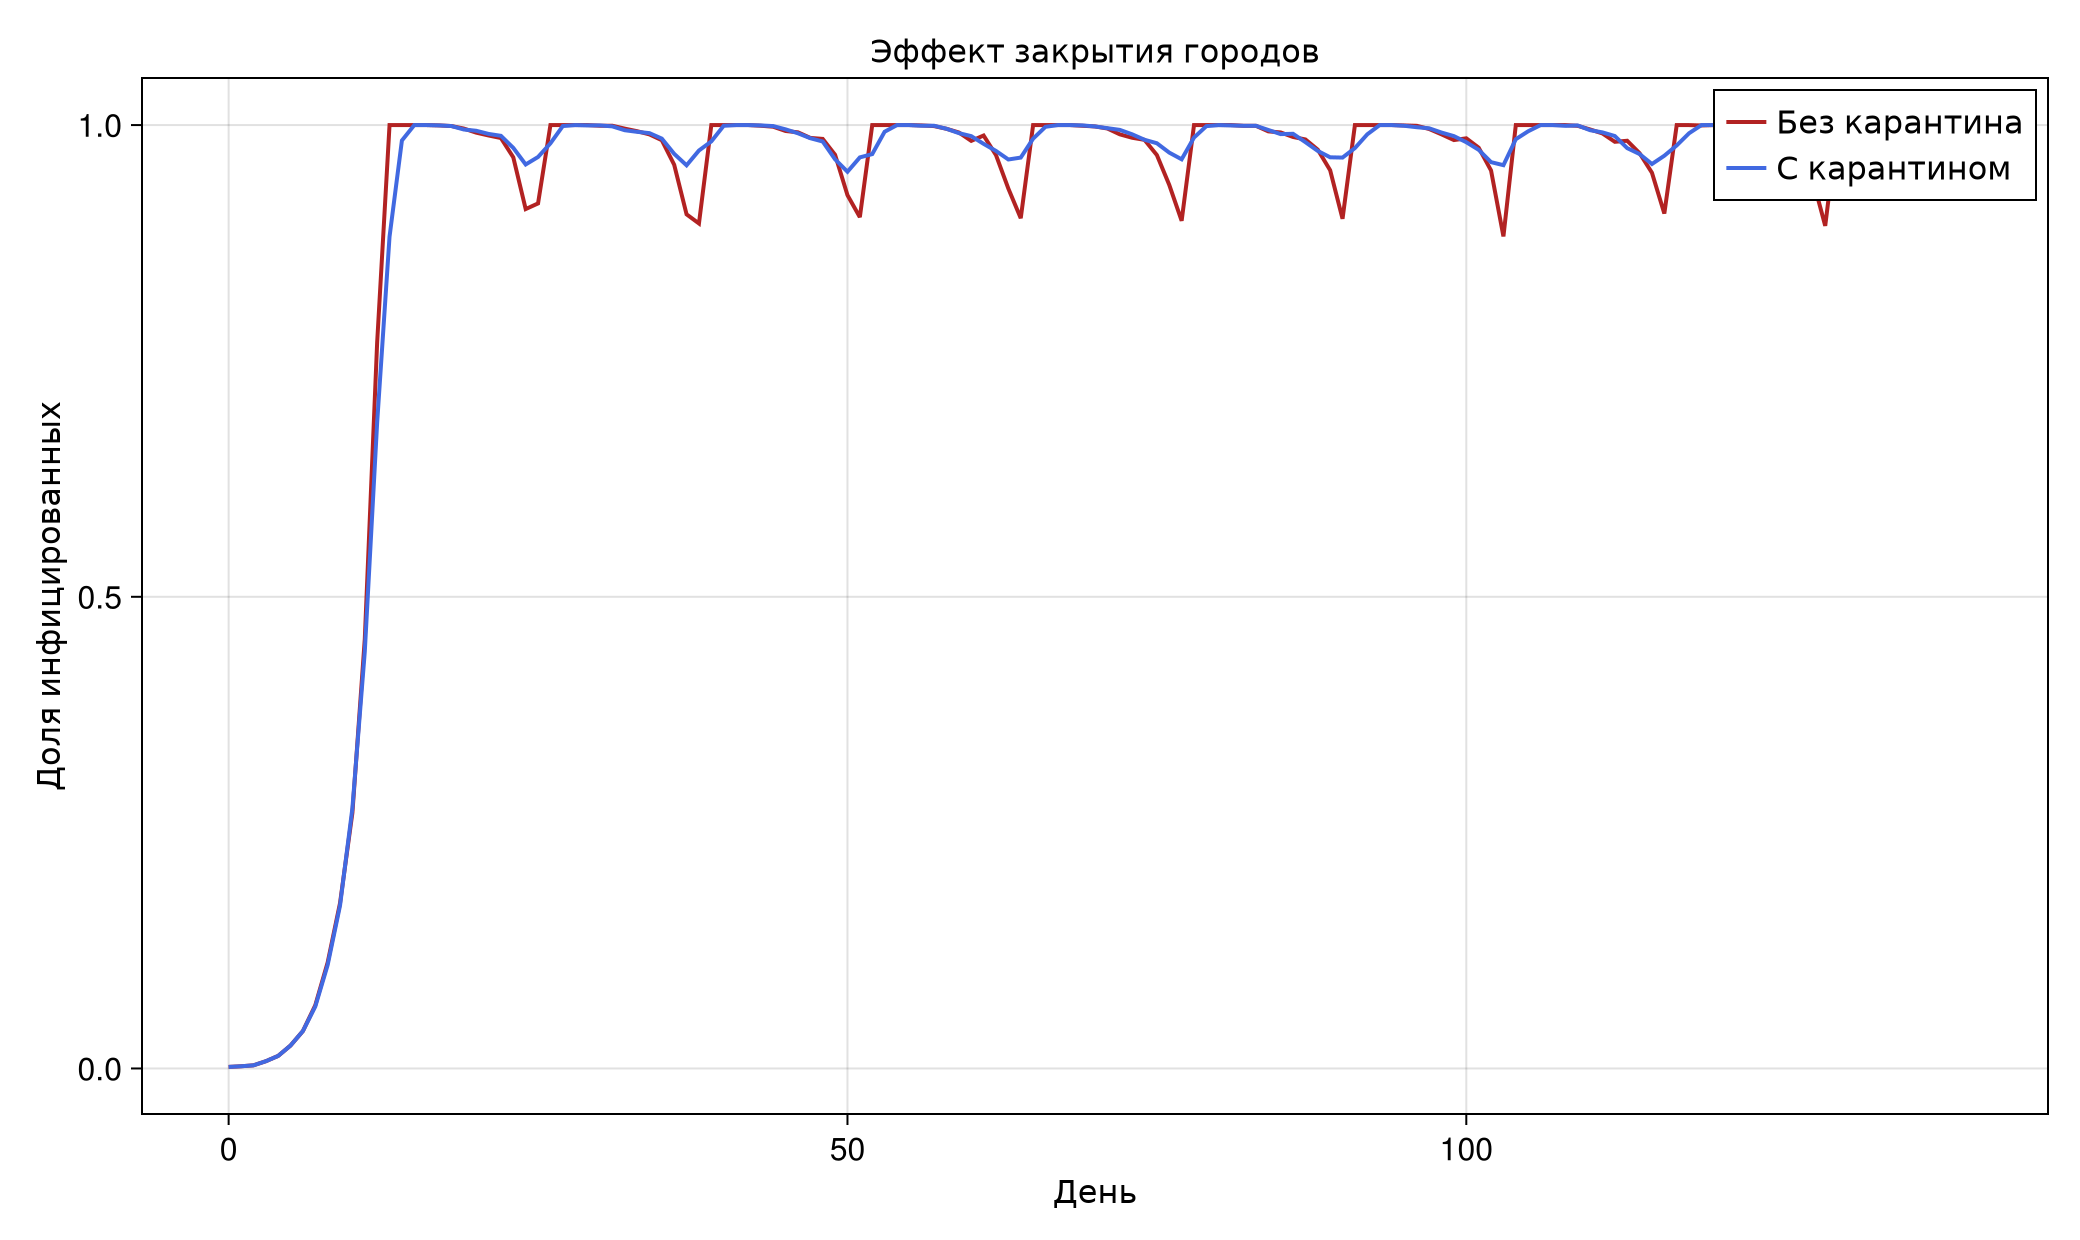

Row,quarantine,mean_peak_fraction,mean_peak_day,mean_deaths,mean_attack_rate,mean_quarantine_days
,Bool,Float64,Float64,Float64,Float64,Float64
1,false,1.0,14.8,517.4,1.0,0.0
2,true,1.0,15.8,511.6,1.0,133.4


In [3]:
fig = Figure(size=(1040, 620))
ax = Axis(fig[1, 1], title="Эффект закрытия городов", xlabel="День", ylabel="Доля инфицированных")
for (flag, colour, label) in ((false, :firebrick, "Без карантина"), (true, :royalblue, "С карантином"))
    frame = example_frames[flag]
    lines!(ax, frame.time, frame.infected_fraction; label, color=colour)
end
axislegend(ax; position=:rt)
save_figure(fig, "sir-quarantine", "quarantine-effect.png";
            report_name="sir-quarantine-effect.png")
display(fig)

metrics_fig = Figure(size=(980, 570))
peak_axis = Axis(metrics_fig[1, 1], title="Средний пик", ylabel="Доля I")
death_axis = Axis(metrics_fig[1, 2], title="Средняя смертность", ylabel="Агенты")
labels = ["нет", "есть"]
barplot!(peak_axis, [1, 2], summary.mean_peak_fraction; color=[:firebrick, :royalblue])
barplot!(death_axis, [1, 2], summary.mean_deaths; color=[:firebrick, :royalblue])
peak_axis.xticks = ([1, 2], labels)
death_axis.xticks = ([1, 2], labels)
save_figure(metrics_fig, "sir-quarantine", "quarantine-metrics.png";
            report_name="sir-quarantine-metrics.png")
summary